# Beyond BLAST

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [2]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

Main.blast_tutorials

In [3]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using CSV
using DataFrames
using .Blast
using .blast_tutorials;

### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [4]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

# open("dimensions.txt", "w") do f
#     write(f, "------------------------ \n")
#     write(f, "IMPORTED REDSHIFT\n")
#     write(f, "Redshift array z_b taken from background has dimensions: $(size(z_b))\n")
#     write(f, "MIN = $(minimum(z_b)) || MAX = $(maximum(z_b)) \n")
#     write(f, "------------------------ \n")
#     write(f, "IMPORTED COMOVING DISTANCE\n")
#     write(f, "Comoving distance array χ_b taken from background has dimensions: $(size(χ_b))\n")
#     write(f, "MIN = $(minimum(χ_b)) || MAX = $(maximum(χ_b)) \n")
#     write(f, "------------------------ \n")
#     write(f, "INTERPOLATED QUANTITIES\n")
#     write(f, "Redshift interpolated array z_of_χ has dimensions: $(size(z_of_χ(χ_b)))\n")
#     write(f, "MIN = $(minimum(z_of_χ(χ_b))) || MAX = $(maximum(z_of_χ(χ_b))) \n")
#     write(f, "Comoving distance interpolated array chi_of_z has dimensions: $(size(chi_of_z(z_b)))\n")
#     write(f, "MIN = $(minimum(chi_of_z(z_b))) || MAX = $(maximum(chi_of_z(z_b))) \n")
#     write(f, "------------------------ \n")
#     write(f, "z_b = z_of_χ(χ_b) and x_b = chi_of_z(z_b), up to numerical precision.\n")
#     write(f, "------------------------ \n")
# end;

### Getting N5K quantities:

In [5]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
n_z_matrix = n5k_bins["dNdz_cl"];

# open("dimensions.txt", "a") do f
#     write(f, "N5K QUANTITIES\n")
#     write(f, "n5k_bins has columns: $(keys(n5k_bins))\n")
#     write(f, "------------------------ \n")
#     write(f, "dN/dz\n")
#     write(f, "numerical density N5K dN/dz (for clustering) has dimensions: $(size(n5k_bins["dNdz_cl"]))\n")
#     write(f, "MIN = $(minimum(n_z_matrix)) || MAX = $(maximum(n_z_matrix)) \n")
#     write(f, "------------------------ \n")
#     write(f, "REDSHIFT z\n")
#     write(f, "redshift N5K z (for clustering) has dimensions: $(size(n5k_bins["z_cl"]))\n")
#     write(f, "MIN = $(minimum(n5k_bins["z_cl"])) || MAX = $(maximum(n5k_bins["z_cl"])) \n")
#     write(f, "------------------------ \n")
#     write(f, "There are $(size(n5k_bins["z_cl"])[1]) redshift values for each of the $(size(n5k_bins["dNdz_cl"])[2]) bins.\n")
#     write(f, "------------------------ \n")
# end;

### Plotting the dN/dz distribution for each bin:

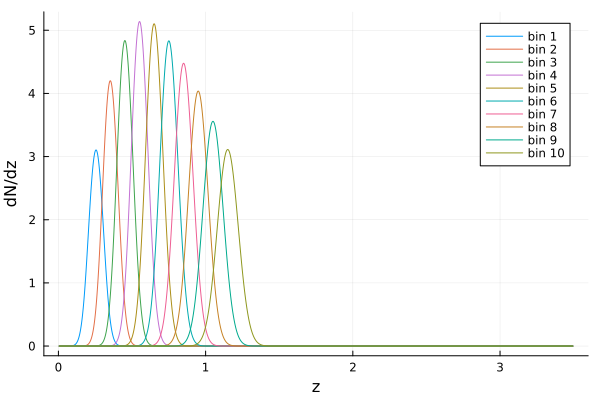

In [6]:
p = plot()
bin = size(n_z_matrix, 2)
for i in 1:bin
    plot!(p, z_n5k, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing n(z)

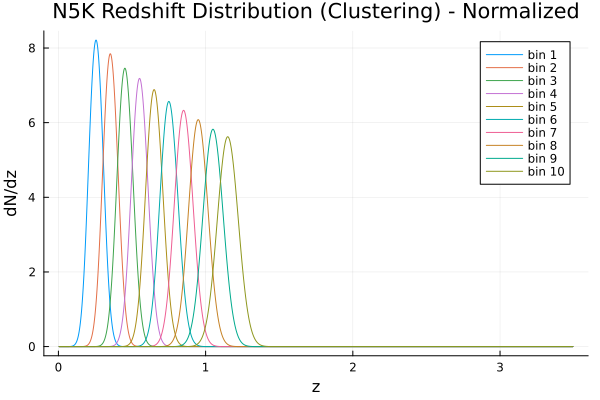

In [7]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:bin]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "N5K dN/dz normalization\n")
    write(f, "The N5K dN/dz values for each bin are normalized such that the integral over redshift is 1.\n")
    write(f, "The norms used for normalization are: \n$(norms)\n")
    write(f, "------------------------ \n")
    write(f, "The normalized N5K dN/dz values for each bin have dimensions: \n$(size(n_z_norm))\n")
    write(f, "MIN = $(minimum(n_z_norm)) || MAX = $(maximum(n_z_norm)) \n")
end;

#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

Dimension of total dN/dz: (2000,)
Dimension of normalized total dN/dz: (2000,)


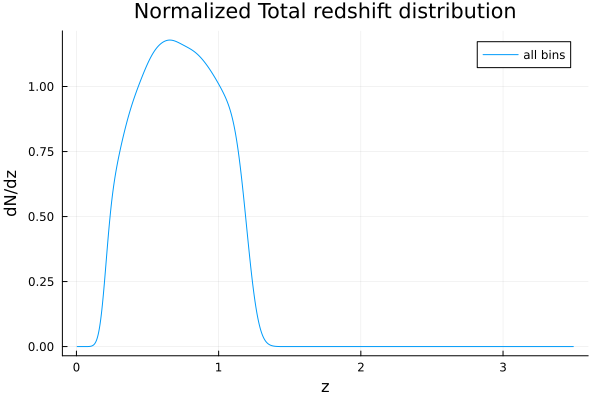

In [8]:
dNdz_tot = sum(n_z_matrix, dims = 2)[:, 1]
#plot(z_n5k, dNdz_tot, label = "all bins", xlabel = "z", ylabel = "dN/dz", title = "Total redshift distribution")
println("Dimension of total dN/dz: $(size(dNdz_tot))")
dNdz_tot_norm = dNdz_tot ./ quadgk(x -> DataInterpolations.AkimaInterpolation(dNdz_tot, z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                                   minimum(z_n5k), maximum(z_n5k))[1]
println("Dimension of normalized total dN/dz: $(size(dNdz_tot_norm))")
plot(z_n5k, dNdz_tot_norm, label = "all bins", xlabel = "z", ylabel = "dN/dz", title = "Normalized Total redshift distribution")

### Creating redshift array and comoving distance array for N5K data

In [9]:
### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = chi_of_z.(z_array); # array of comoving distances corresponding to z_range

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT ARRAY\n")
    write(f, "Redshift z_array is a vector or dimension: $(size(z_array))\n")
    write(f, "MIN = $(minimum(z_array)) || MAX = $(maximum(z_array))\n")
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCE ARRAY\n")
    write(f, "Comoving distance chi_array is a vector or dimension: $(size(chi_array))\n")
    write(f, "MIN = $(minimum(chi_array)) || MAX = $(maximum(chi_array))\n")
    write(f, "------------------------ \n")
    write(f, "Values of normalized N5K dN/dz (clustering) for the first bin are: \n$(n_z_norm[:, 1])\n")
    write(f, "------------------------ \n")
end;

### Setting number of COMOVING DISTANCE POINTS

In [10]:
cosmo = Blast.FlatΛCDM()
n_chi = 200;                  # Number of comoving distance points

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS: $n_chi\n")
end;

### Defining redshift array and comoving distance array with our $\chi_{min}$ and $\chi_{max}$

In [11]:
# Array of comoving distances
x_array = LinRange(26, 7000, n_chi)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCES AND CORRESPONDING REDSHIFTS\n")
    write(f, "Array of comoving distances x_array has dimensions: $(size(x_array))\n")
    write(f, "MIN = $(minimum(x_array)) || MAX = $(maximum(x_array)) \n")
    write(f, "Array of redshifts z_range has dimensions: $(size(z_range))\n")
    write(f, "MIN = $(minimum(z_range)) || MAX = $(maximum(z_range)) \n")
    write(f, "------------------------ \n")
end;

### BIAS

In [12]:
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = zeros(size(z_range))
b_z_array = b_0 .* sqrt.(1 .+ z_range); # bias as a function of redshift

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

### GROWTH FACTOR

In [13]:
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

### PLOTTING BIAS $b(z)$, COMOVING DISTANCE $\chi(z)$, and GROWTH FACTOR $D(z)$

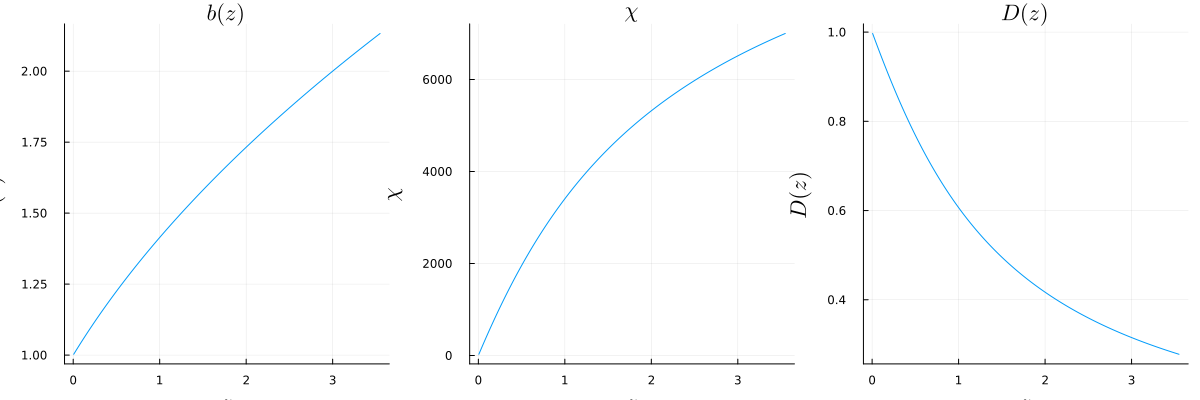

In [14]:
p1 = plot(z_range, 
          b_z_array, 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"$b(z)$", 
          title=L"$b(z)$")
p2 = plot(z_range, 
          x_array, 
          label=L"z and $\chi$",
          title = L"$\chi$",
          xlabel=L"$z$", 
          ylabel=L"$\chi$")
p3 = plot(z_range, 
          growth_array, 
          label="Growth Factor D(z)", 
          xlabel=L"$z$", 
          ylabel=L"$D(z)$", 
          title=L"$D(z)$")
plot(p1, p2, p3, layout=(1,3), titlefontsize=15, labelfontsize=15, legendfontsize=15, size=(1200,400), legend=false)

In [15]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Array of redshifts: z_range has dimensions: $(size(z_range)) || z_array has dimensions: $(size(z_array))\n")
  end;

### GETTING $n(z)$

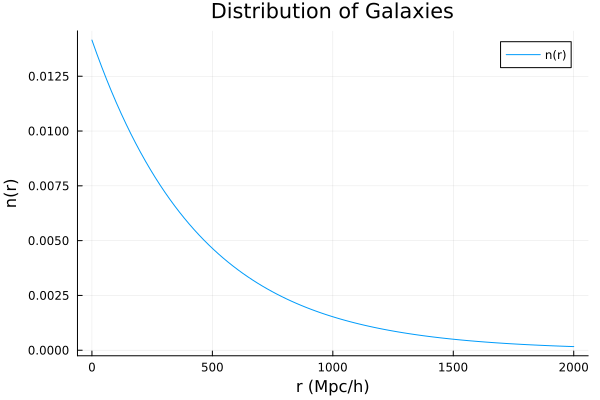

In [16]:
n_0 = 141.5*1e-4 # in units of h^3 Mpc^-3
r_0 = 449. # in units of Mpc/h
r = LinRange(0., 2000., 100) # in units of Mpc/h
n_r = n_0 .* exp.(−r ./r_0)
plot(r, n_r, label="n(r)", xlabel="r (Mpc/h)", ylabel="n(r)", title="Distribution of Galaxies")

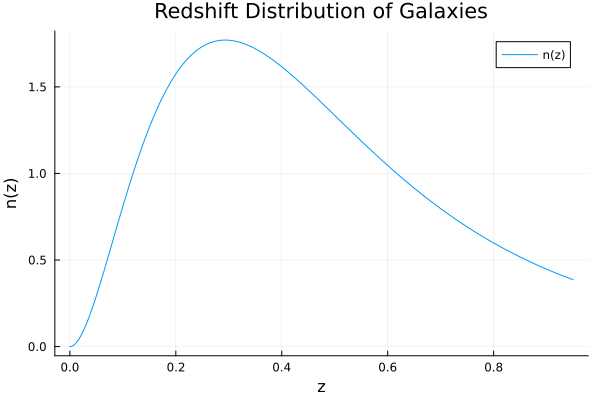

In [17]:
nz_data = CSV.read("blast_code/data/dNdz_normalized.csv", DataFrame)
nz = nz_data.dN_dz_normalized #n_1e-4_h3_per_Mpc3
z_nz = nz_data.z
plot(z_nz, nz, label="n(z)", xlabel="z", ylabel="n(z)", title="Redshift Distribution of Galaxies")

In [18]:
# n_bins = size(n_z_norm, 2) # number of tomographic bins
# nz = zeros(n_chi, n_bins) # size nx per number of bins
# for b in 1:n_bins
#      nz_func = DataInterpolations.AkimaInterpolation(n_z_norm[:, b], z_array, extrapolation=ExtrapolationType.Linear)
#      nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
#      #println("Bin $b: Normalized n(z) integral: ", nz_norm)
#      nz[:, b] = nz_func.(z_range)
#      #println("Bin $b: n(z) has size: ", size(nz))
# end

# open("dimensions.txt", "a") do f
#     write(f, "------------------------ \n")
#     write(f, "Number of tomographic bins: $(n_bins)\n")
#     write(f, "Size of n(z) array nz: $(size(nz))\n")
#   end;

dNdz from BLAST

In [19]:
# nz_func = DataInterpolations.AkimaInterpolation(dNdz_tot_norm, z_array, extrapolation=ExtrapolationType.Linear)
# nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
# nz = nz_func.(z_range);
# println("Size of nz: $(size(nz))")

n(z) from SuperFAB

In [20]:
nz_func = DataInterpolations.AkimaInterpolation(nz, z_array, extrapolation=ExtrapolationType.Linear)
nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
nz = nz_func.(z_range);
println("Size of nz: $(size(nz))")

Size of nz: (200,)


In [21]:
prefac = x_array.^2 .* b_z_array .* growth_array
kernel_composed = reshape(prefac, :, 1) .* nz;
function compute_kernel_W_z(
    z_range::AbstractVector{<:Number},
    x_array::AbstractVector{<:Number},
    b_z_array::AbstractVector{<:Number},
    growth_array::AbstractVector{<:Number},
    nz::AbstractMatrix{<:Number}
)
    prefac = x_array.^2 .* b_z_array .* growth_array
    kernel_composed = reshape(prefac, :, 1) .* nz
    return kernel_composed
end

compute_kernel_W_z (generic function with 1 method)

In [22]:
# open("dimensions.txt", "a") do f
#     write(f, "------------------------ \n")
#     write(f, "Number of tomographic bins n_bins: $(n_bins)\n")
#     write(f, "Size of n(z) array nz: $(size(nz))\n")
#     write(f, "Size of prefactor array (chi^2 * b(z) * D(z)): $(size(prefac))\n")
#     write(f, "Size of kernel_composed array: $(size(kernel_composed))\n")
#     write(f, "The prefactor array is the product of chi^2, b(z), and D(z) evaluated at the redshifts corresponding to the comoving distances in x_array.\n")
#     write(f, "Size of array z_range: $(size(z_range))\n")
#     write(f, "Size of array x_array: $(size(x_array))\n")
#     write(f, "Size of array b_z_array: $(size(b_z_array))\n")
#     write(f, "Size of array growth_array: $(size(growth_array))\n")
#     write(f, "Size of array nz: $(size(nz))\n")
#   end;

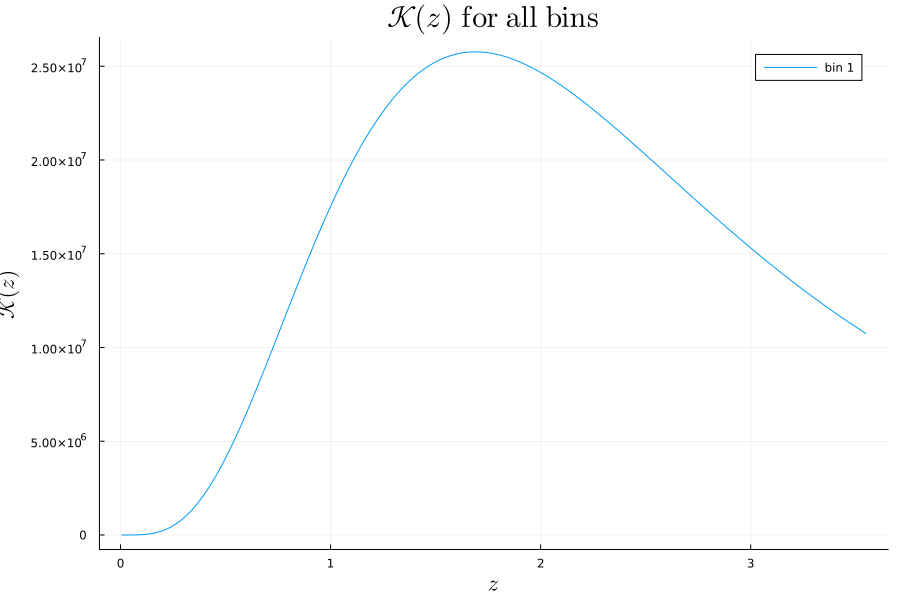

In [23]:
p = plot(
    xlabel=L"$z$",
    ylabel=L"\mathcal{K}(z)",
    title=L"\mathcal{K}(z)\ \mathrm{for\ all\ bins}",
    xlabelfontsize=15,
    ylabelfontsize=15,
    titlefontsize=20,
    legendfontsize=8,
    size=(900, 600)
)
for b in 1:size(kernel_composed, 2)
    plot!(p, z_range, kernel_composed[:, b], label="bin $b")
end
display(p)

In [58]:
ℓ = Blast.ℓ
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
chi = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
zed = z_of_χ.(chi)                                      # array of redshifts corresponding to the comoving distances
n_z = length(zed)
zmin = minimum(zed)                                     # minimum redshift
zmax = maximum(zed)                                     # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 2^(12)+1                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(12)+1;                                         # number of integration points
#N = 119;

In [59]:
z_cheb_nodes = Blast.get_clencurt_grid_z(zmin, zmax, n_cheb)

chi_interp = DataInterpolations.AkimaInterpolation(chi, z_range, extrapolation=ExtrapolationType.Linear)
chi_cheb = chi_interp.(z_cheb_nodes)
println("Size of chi_cheb: ", size(chi_cheb))
b_interp = DataInterpolations.AkimaInterpolation(b_z_array, z_range, extrapolation=ExtrapolationType.Linear)
b_cheb = b_interp.(z_cheb_nodes)
println("Size of b_cheb: ", size(b_cheb))
D_interp = DataInterpolations.AkimaInterpolation(growth_array, z_range, extrapolation=ExtrapolationType.Linear)
D_cheb = D_interp.(z_cheb_nodes)
println("Size of D_cheb: ", size(D_cheb))
n_interps = DataInterpolations.AkimaInterpolation(nz, z_range, extrapolation=ExtrapolationType.Linear)
n_cheb = n_interps.(z_cheb_nodes)
println("Size of n_cheb: ", size(n_cheb))

W_vals = zeros(length(z_cheb_nodes))
W_vals .= chi_cheb.^2 .* b_cheb .* D_cheb .* n_cheb # dimensions: (n_cheb, n_bins)
println("Size of W_vals: ", size(W_vals))

# T_z = Blast.generate_cheb_matrix_z(z_cheb_nodes, zmin, zmax)
# println("Size of T_z: ", size(T_z))
# cheb_coeff_W = T_z \ W_vals;
# println("Size of cheb_coeff_W: ", size(cheb_coeff_W))

Size of chi_cheb: (4097,)
Size of b_cheb: (4097,)
Size of D_cheb: (4097,)
Size of n_cheb: (4097,)
Size of W_vals: (4097,)


In [60]:
using BenchmarkTools

@time chi_interp = DataInterpolations.AkimaInterpolation(chi, z_range, extrapolation=ExtrapolationType.Linear)
@time chi_cheb = chi_interp.(z_cheb_nodes)
@time W_vals .= chi_cheb.^2 .* b_cheb .* D_cheb .* n_cheb;

  0.000084 seconds (37 allocations: 51.562 KiB)
  0.000107 seconds (3 allocations: 32.297 KiB)
  0.000092 seconds (10 allocations: 384 bytes)


In [61]:
#save the objects to .npy files
npzwrite("chi_cheb.npy", chi_cheb)
npzwrite("b_cheb.npy", b_cheb)
npzwrite("D_cheb.npy", D_cheb)
npzwrite("n_cheb.npy", n_cheb)
npzwrite("W_cheb.npy", W_vals)
# npzwrite("T_z.npy", T_z)
# npzwrite("cheb_coeff_W.npy", cheb_coeff_W)

In [62]:
k_grid = Blast.get_clencurt_grid(kmin, kmax, N)
kp_grid = Blast.get_clencurt_grid(kmin, kmax, N) # for the second integral in the double Bessel case
kpp_grid = Blast.get_clencurt_grid(kmin, kmax, N); # for the third integral in the double Bessel case

In [63]:
# function compute_double_bessel_z_integral(k_grid, z_cheb_nodes, zmin, zmax, W_vals, ℓ)
#     if zmin >= zmax 
#         throw(DomainError("The integration range is unphysical. Make sure zmin < zmax.")) 
#     end
    
#     Nz = length(z_cheb_nodes)
#     Nk = length(k_grid)
#     n_bins = size(W_vals, 2)

#     χ_nodes = chi_interp.(z_cheb_nodes)

#     z_weights = FastTransforms.clenshawcurtisweights(
#         FastTransforms.chebyshevmoments1(Float64, Nz)
#     ) * (zmax - zmin) / 2

#     weightW = z_weights .* W_vals

#     J = zeros(Nz, Nk)
#     Threads.@threads for i in 1:Nz
#         J[i, :] = @views SpecialFunctions.sphericalbesselj.(ℓ, k_grid * χ_nodes[i]) # dimensions: (n_cheb, N)
#     end

#     I = zeros(Nk)
#     @tullio I[ik] := weightW[iz] * J[iz, ik]^2  # dimensions: (N, n_bins)

#     return I
# end;

In [64]:
# when k1 is different from k2 and from k
function compute_double_bessel_z_integral(k_grid, kp_grid, z_cheb_nodes, zmin, zmax, W_vals, ell)
    Nz = length(z_cheb_nodes)
    Nk = length(k_grid)
    Nkp = length(kp_grid)

    χ_nodes = chi_interp.(z_cheb_nodes)

    z_weights = FastTransforms.clenshawcurtisweights(
        FastTransforms.chebyshevmoments1(Float64, Nz)
    ) * (zmax - zmin) / 2

    weightW = z_weights .* W_vals

    J1 = zeros(Nz, Nk)
    J2 = zeros(Nz, Nkp)

    Threads.@threads for i in 1:Nz
        J1[i, :] = SpecialFunctions.sphericalbesselj.(ell, k_grid * χ_nodes[i])
        J2[i, :] = SpecialFunctions.sphericalbesselj.(ell, kp_grid * χ_nodes[i])
    end
    I = zeros(Nk, Nkp)
    @tullio I[ik, ikp] := weightW[iz] * J1[iz, ik] * J2[iz, ikp]

    return I
end

compute_double_bessel_z_integral (generic function with 1 method)

In [65]:
I_A = zeros(length(ℓ), length(k_grid), length(kp_grid))
I_B = zeros(length(ℓ), length(k_grid), length(kp_grid))
for idx in eachindex(ℓ)
    I_A[idx, :, :] = compute_double_bessel_z_integral(k_grid, kp_grid, z_cheb_nodes, zmin, zmax, W_vals, ℓ[idx])
    I_B[idx, :, :] = compute_double_bessel_z_integral(k_grid, kpp_grid, z_cheb_nodes, zmin, zmax, W_vals, ℓ[idx])
    println("Computed double Bessel integral for ℓ = ", ℓ[idx])
end;

Computed double Bessel integral for ℓ = 2.0
Computed double Bessel integral for ℓ = 2.492946194634132
Computed double Bessel integral for ℓ = 3.971298300156713
Computed double Bessel integral for ℓ = 6.433597361523084
Computed double Bessel integral for ℓ = 9.877413386836713
Computed double Bessel integral for ℓ = 14.299347745457478
Computed double Bessel integral for ℓ = 19.695036522039967
Computed double Bessel integral for ℓ = 26.059154823191424
Computed double Bessel integral for ℓ = 33.385422032497665
Computed double Bessel integral for ℓ = 41.66660800873399
Computed double Bessel integral for ℓ = 50.894540221141625
Computed double Bessel integral for ℓ = 61.06011181472877
Computed double Bessel integral for ℓ = 72.15329059763691
Computed double Bessel integral for ℓ = 84.16312894170306
Computed double Bessel integral for ℓ = 97.07777458644667
Computed double Bessel integral for ℓ = 110.88448233582058
Computed double Bessel integral for ℓ = 125.56962663618027
Computed double Besse

In [66]:
npzwrite("I_A.npy", I_A)
npzwrite("I_B.npy", I_B)

Dimension of k points: 200
Dimension of Pklin: 50
Dimension of Pknonlin: 50


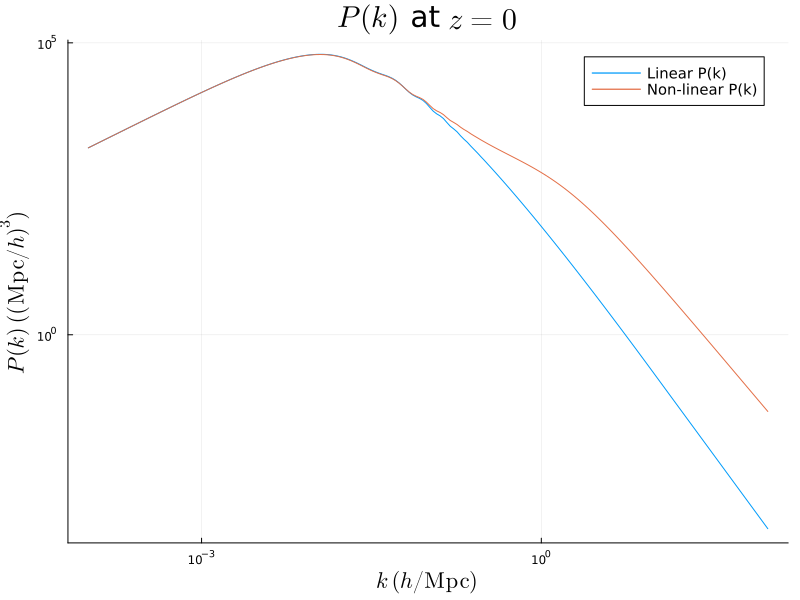

In [67]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

println("Dimension of k points: ", size(k)[1])
println("Dimension of Pklin: ", size(Pklin)[1])
println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)

In [68]:
Pk_grid = power_spectrum_nl.(k_grid, first(z), last(z));

In [69]:
Nk = length(k_grid)
w_k = FastTransforms.clenshawcurtisweights(
      FastTransforms.chebyshevmoments1(Float64, Nk)) * (kmax - kmin) / 2

# Pk_grid deve avere la stessa lunghezza di k_grid
wktot = @. w_k * k_grid^2 * Pk_grid;

In [70]:
println("Size of Pk_grid: ", size(Pk_grid))
println("Size of I_A: ", size(I_A))
println("Size of I_B: ", size(I_B))

Size of Pk_grid: (4097,)
Size of I_A: (22, 4097, 4097)
Size of I_B: (22, 4097, 4097)


In [ ]:
S = zeros(Float64, length(ℓ), size(I_A, 3), size(I_B, 3))
@tullio S[li, a, b] := wktot[k] * I_A[li, k, a] * I_B[li, k, b];

22×4097×4097 Array{Float64, 3}:
[:, :, 1] =
 0.0294139  0.0294007  0.0293406  …  -40.1597        -39.8391
 0.0233423  0.0232933  0.0231234      -7.66552        -7.56705
 0.0296418  0.029634   0.0295909       4.59512         4.4944
 0.0241803  0.0241286  0.0239491      -0.0295547      -0.0284346
 0.0299137  0.0299258  0.0299466      -9.28428e-5     -8.73559e-5
 0.0269254  0.026869   0.0266725  …   -1.64469e-9     -1.50439e-9
 0.0260936  0.0261388  0.0262683       1.04685e-15     9.25179e-16
 0.0291651  0.0291519  0.0290924      -4.46752e-24    -3.79205e-24
 0.021357   0.0214196  0.0216075      -3.67112e-34    -2.97485e-34
 0.0244698  0.0245156  0.0246481      -8.64887e-47    -6.65063e-47
 0.0180929  0.018078   0.0180205  …    3.18117e-62     2.3075e-62
 0.0177911  0.0178065  0.0178466      -9.96573e-79    -6.77909e-79
 0.0264329  0.0264061  0.0263046       3.35355e-97     2.12681e-97
 0.0268222  0.0267917  0.026678        1.22442e-119    7.19775e-120
 0.0174745  0.0174868  0.017517     

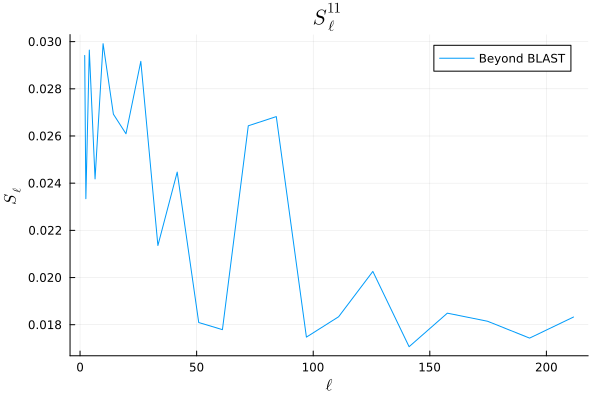

In [77]:
plot(
    ℓ,
    S[:, 1, 1],
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"S_\ell",
    title = L"S_\ell^{11}"
)

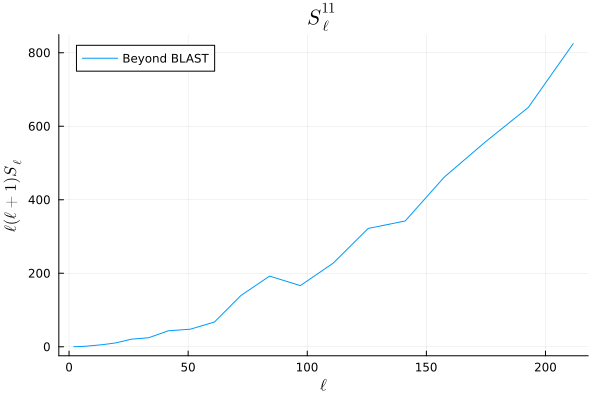

In [ ]:
plot(
    ℓ,
    S[:, 1, 1] .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"S_\ell^{11}"
)

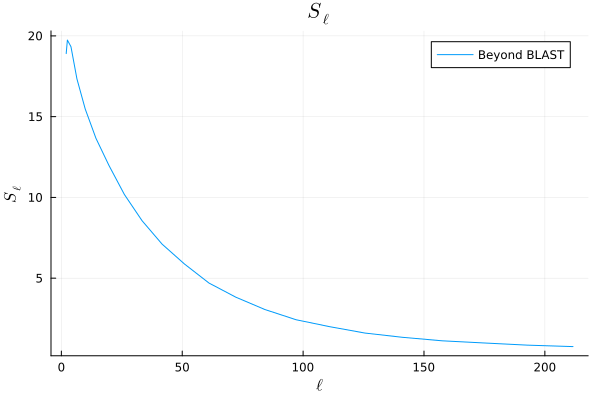

In [78]:
S_full = zeros(Float64, length(ℓ))
@tullio S_full[li] := w_k[a] * w_k[b] * S[li, a, b]
# plot
plot(ℓ, S_full, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell")

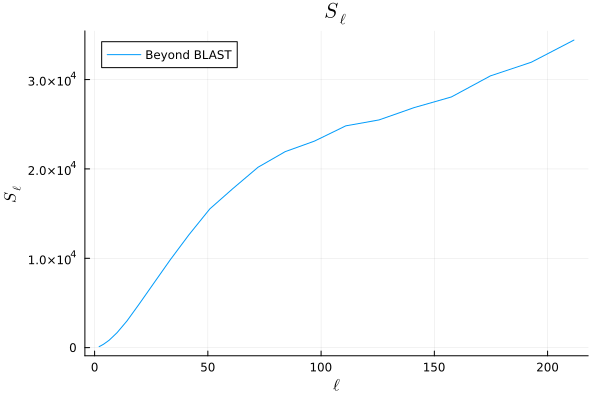

In [80]:
plot(ℓ, S_full .* ℓ .* (ℓ .+ 1), label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell")